<a href="https://colab.research.google.com/github/nurfnick/Data_Viz/blob/main/Content/Data_Collecting/Exam2Review.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exam 2 Review

## SQL

Can you get big query to work?  Use `baseball.games_post_wide`

1. How many games are in the database?
2. Compute the average `durationMinutes` by `venueCity`.
3. Find the average `durationMinutes` for games that have `attendance` above the 75th percentile

In [1]:


from google.colab import auth
auth.authenticate_user()
print('Authenticated')



Authenticated


In [3]:
%%bigquery --project pic-math
SELECT
  COUNT(*) as total_rows
FROM `bigquery-public-data.baseball.games_post_wide`

Query is running:   0%|          |

Downloading:   0%|          |

,total_rows
0,8676


There are 8676 games in the data.

2. Compute the average `durationMinutes` by `venueCity`.

In [6]:
%%bigquery --project pic-math

SELECT AVG(durationMinutes) as avg_duration, venueCity, COUNT(*) as total_rows
FROM `bigquery-public-data.baseball.games_post_wide`
GROUP BY venueCity

Query is running:   0%|          |

Downloading:   0%|          |

,avg_duration,venueCity,total_rows
0,186.545936,Cleveland,1132
1,221.000000,Boston,345
2,191.120760,Toronto,1474
3,262.994865,San Francisco,779
4,191.000000,"Flushing, Queens",290
5,234.936023,Los Angeles,1735
6,176.696552,Chicago,1305
7,245.077810,Washington,1041
8,195.029565,Arlington,575


Why is LA so long?

Find the average durationMinutes for games that have attendance above the 75th percentile

In [20]:
%%bigquery --project pic-math

SELECT AVG(durationMinutes) as avg_duration, venueCity, COUNT(*) as total_rows
FROM `bigquery-public-data.baseball.games_post_wide`
WHERE attendance >(SELECT PERCENTILE_CONT(attendance, 0.75) OVER() as percentile_75 FROM `bigquery-public-data.baseball.games_post_wide` LIMIT 1)
GROUP BY venueCity

Query is running:   0%|          |

Downloading:   0%|          |

,avg_duration,venueCity,total_rows
0,205.000000,Toronto,316
1,234.936023,Los Angeles,1735


In [22]:
%%bigquery --project pic-math

SELECT AVG(attendance) as avg, venueCity, COUNT(*) as total_rows
FROM `bigquery-public-data.baseball.games_post_wide`
GROUP BY venueCity

Query is running:   0%|          |

Downloading:   0%|          |

,avg,venueCity,total_rows
0,37800.231449,Cleveland,1132
1,39530.000000,Boston,345
2,49420.307327,Toronto,1474
3,43405.672657,San Francisco,779
4,44747.000000,"Flushing, Queens",290
5,53425.062248,Los Angeles,1735
6,42341.984674,Chicago,1305
7,43893.657061,Washington,1041
8,47745.321739,Arlington,575


## Web Scraping

1. Give me a fun wikipage with a table.
2. Create some viz from the table.
3. Group by categorical and compute some stats.

In [23]:
url = "https://en.wikipedia.org/wiki/List_of_Family_Guy_episodes"

import requests
import pandas as pa
from bs4 import BeautifulSoup

headers = {'User-Agent': 'Mozilla/5.0'}
r = requests.get(url, headers=headers)
html_contents = r.text
html_soup = BeautifulSoup(html_contents,"lxml")

In [32]:

tables = html_soup.find_all('table', class_="wikitable")

df = pa.read_html(str(tables))[0]

/tmp/ipykernel_19639/413905169.py:3: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  df = pa.read_html(str(tables))[0]


In [34]:
df.columns = df.columns.droplevel(0)

In [38]:
df.head()

,Season,Episodes,Episodes.1,First released,Last released,Network,Rank,Average viewers (in millions)
0,1,7,7,"January 31, 1999","May 16, 1999",Fox,33,14.12[17]
1,2,21,21,"September 23, 1999","August 1, 2000",Fox,114,6.74
2,3,22[a],22[a],"July 11, 2001","November 9, 2003[a]",Fox,125,4.50[18]
3,4,30,30,"May 1, 2005","May 21, 2006",Fox,68,7.90[19]
4,5,18,18,"September 10, 2006","May 20, 2007",Fox,71,8.69[20]


<Axes: >

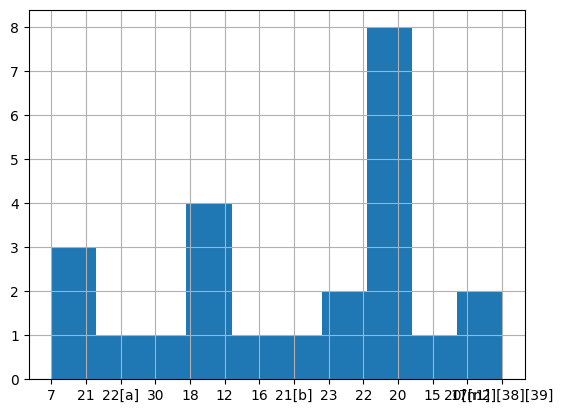

In [37]:
df.Episodes.hist()

<Axes: xlabel='Network'>

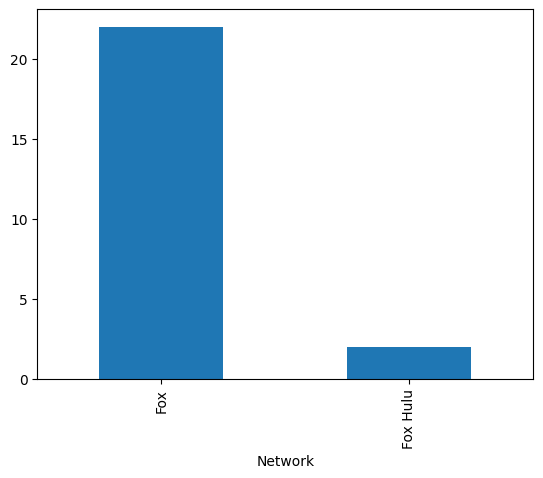

In [42]:
df.Network.value_counts().plot(kind = 'bar')

In [44]:
df.groupby('Network').mean('Season')

,Season
Network,
Fox,11.5
Fox Hulu,23.5
